# Comprehensive EDA: `hospital_ransomware_master.csv`

This notebook performs a broad exploratory data analysis (EDA) of the uploaded hospital ransomware dataset.

## What this notebook covers
- Dataset shape, preview, and data types
- Missing-value analysis
- Duplicate and key-integrity checks
- Target-variable distributions
- Categorical-variable exploration
- Numeric summaries and selected distributions
- Trends over time
- Group comparisons for ransomware vs. non-ransomware records
- Correlation review for selected numeric features
- Modeling-readiness checks

> File analyzed: `/mnt/data/hospital_ransomware_master.csv`


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 120

DATA_PATH = "/mnt/data/hospital_ransomware_master.csv"
df = pd.read_csv(DATA_PATH)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

print(f"Loaded dataset: {DATA_PATH}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")


Loaded dataset: /mnt/data/hospital_ransomware_master.csv
Shape: 61,444 rows x 117 columns


## 1. Dataset overview

In [2]:
display(df.head())
display(df.sample(5, random_state=42))


,ccn,cbsa,fte_employees,total_days,beds,total_discharges,charity_care_cost,bad_debt_expense,cost_of_uncompensated_care,total_unreimbursed_and_uncompensated_care,total_salaries,overhead_costs,depreciation_cost,total_costs,contract_labor,cash_on_hand_and_in_banks,accounts_receivable,total_current_assets,total_assets,total_current_liabilities,total_long_term_liabilities,total_liabilities,total_fund_balances,inpatient_revenue,outpatient_revenue,total_patient_revenue,net_patient_revenue,total_operating_expense,net_income,cost_to_charge_ratio,medicaid_net_revenue,report_year,net_profit_margin,operating_margin,cost_to_revenue_ratio,outpatient_revenue_share,inpatient_revenue_share,salary_cost_share,overhead_cost_share,depreciation_cost_share,contract_labor_share,charity_care_pct_revenue,bad_debt_pct_revenue,revenue_per_bed,cost_per_bed,net_income_per_bed,revenue_per_discharge,cost_per_discharge,net_income_per_discharge,revenue_per_day,cost_per_day,revenue_per_fte,cost_per_fte,salary_per_fte,occupancy_rate,discharge_per_bed,debt_to_equity,asset_turnover,equity_ratio,liability_ratio,current_ratio,net_working_capital,medicaid_revenue_share,net_patient_revenue_yoy_change,net_patient_revenue_yoy_pct_change,total_costs_yoy_change,total_costs_yoy_pct_change,net_income_yoy_change,net_income_yoy_pct_change,beds_yoy_change,beds_yoy_pct_change,fte_employees_yoy_change,fte_employees_yoy_pct_change,net_patient_revenue_2yr_rolling_median,total_costs_2yr_rolling_median,years_in_dataset,pre_covid,covid_year,post_covid,log_total_costs,log_net_patient_revenue,log_total_assets,log_total_liabilities,log_fte_employees,log_total_salaries,is_profitable,high_charity,bed_tier,revenue_tier,hospital_type,birthing_center,emergency_services,hospital_ownership,hospital_rating,mort_participation,safety_participation,readm_participation,ptexp_participation,te_participation,engagement_index,domains_reporting,mort_better,mort_worse,safety_better,safety_worse,readm_better,readm_worse,net_performance_score,net_performance_rate,performance_ratio,breach_count,total_individuals_affected,first_breach_year,last_breach_year,had_ransomware,breach_types,had_breach
0,10001,20020.0,2405.80,94934.0,398.0,18489.0,5256594.0,104422708.0,24479384.0,28691031.0,136034568.0,177015727.0,20884213.0,231992999.0,204809.0,5836798.0,238954076.0,68781537.0,393203543.0,35131255.0,120117898.0,155249153.0,237954390.0,702457034.0,748728652.0,1.451186e+09,290209919.0,313050295.0,1125576.0,0.179295,21186859.0,2014,0.003878,0.003596,0.159864,0.515943,0.484057,0.586374,0.763022,0.090021,0.001506,0.018113,0.359818,7.291707e+05,582896.982412,2828.080402,15696.355617,12547.622857,60.878144,3056.965039,2443.729317,120629.278826,96430.708704,56544.420983,0.653500,46.454774,0.652432,0.738065,0.605168,0.394832,1.957845,33650282.0,0.073005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,290209919.0,231992999.0,0,1,0,0,19.262218,19.486115,19.789838,18.860542,7.786053,18.728420,1,0,Major,Q4_High,Acute Care,1.0,1.0,Government,4.0,1.0,0.875,1.0,1.0,0.916667,0.958333,5.0,0.0,0.0,0.428571,0.0,0.0,0.0,3.0,0.12,0.12,0,0.0,NaN,NaN,0,NaN,0
1,10001,20020.0,2379.50,89693.0,400.0,18484.0,4286307.0,90985897.0,20350620.0,25026782.0,139432336.0,181268692.0,20756178.0,238867113.0,NaN,8339540.0,246020717.0,64631457.0,391583329.0,37199604.0,115632336.0,152831940.0,238751389.0,698495267.0,852176750.0,1.550672e+09,299070211.0,320701028.0,605488.0,0.168500,8612038.0,2015,0.002025,0.001888,0.154041,0.549553,0.450447,0.583723,0.758868,0.086894,NaN,0.014332,0.304229,7.476755e+05,597167.782500,1513.720000,16179.950822,12922.912411,32.757412,3334.376272,2663.163380,125686.157176,100385.422568,58597.325489,0.614336,46.210000,0.640130,0.763746,0.609708,0.390292,1.737423,27431853.0,0.028796,8860292.0,3.053063,6874114.0,2.963070,-520088.0,-46.206387,2.0,0.502513,-26.30,-1.093191,294640065.0,235430056.0,1,1,0,0,19.291418,19.516189,19.785709,18.844849,7.775066,18.753090,1,0,Major,Q4_High,Acute Care,1.0,1.0,Government,4.0,1.0,0.875,1.0,1.0,0.916667,0.

,ccn,cbsa,fte_employees,total_days,beds,total_discharges,charity_care_cost,bad_debt_expense,cost_of_uncompensated_care,total_unreimbursed_and_uncompensated_care,total_salaries,overhead_costs,depreciation_cost,total_costs,contract_labor,cash_on_hand_and_in_banks,accounts_receivable,total_current_assets,total_assets,total_current_liabilities,total_long_term_liabilities,total_liabilities,total_fund_balances,inpatient_revenue,outpatient_revenue,total_patient_revenue,net_patient_revenue,total_operating_expense,net_income,cost_to_charge_ratio,medicaid_net_revenue,report_year,net_profit_margin,operating_margin,cost_to_revenue_ratio,outpatient_revenue_share,inpatient_revenue_share,salary_cost_share,overhead_cost_share,depreciation_cost_share,contract_labor_share,charity_care_pct_revenue,bad_debt_pct_revenue,revenue_per_bed,cost_per_bed,net_income_per_bed,revenue_per_discharge,cost_per_discharge,net_income_per_discharge,revenue_per_day,cost_per_day,revenue_per_fte,cost_per_fte,salary_per_fte,occupancy_rate,discharge_per_bed,debt_to_equity,asset_turnover,equity_ratio,liability_ratio,current_ratio,net_working_capital,medicaid_revenue_share,net_patient_revenue_yoy_change,net_patient_revenue_yoy_pct_change,total_costs_yoy_change,total_costs_yoy_pct_change,net_income_yoy_change,net_income_yoy_pct_change,beds_yoy_change,beds_yoy_pct_change,fte_employees_yoy_change,fte_employees_yoy_pct_change,net_patient_revenue_2yr_rolling_median,total_costs_2yr_rolling_median,years_in_dataset,pre_covid,covid_year,post_covid,log_total_costs,log_net_patient_revenue,log_total_assets,log_total_liabilities,log_fte_employees,log_total_salaries,is_profitable,high_charity,bed_tier,revenue_tier,hospital_type,birthing_center,emergency_services,hospital_ownership,hospital_rating,mort_participation,safety_participation,readm_participation,ptexp_participation,te_participation,engagement_index,domains_reporting,mort_better,mort_worse,safety_better,safety_worse,readm_better,readm_worse,net_performance_score,net_performance_rate,performance_ratio,breach_count,total_individuals_affected,first_breach_year,last_breach_year,had_ransomware,breach_types,had_breach
58926,520096,39540.0,1007.11,41292.0,285.0,7709.0,7362919.0,11216803.0,10674374.0,19642425.0,71409877.0,195671345.0,21003583.0,253648933.0,8037264.0,9741.0,95177822.0,75581887.0,293804799.0,60455683.0,5443749.0,65899432.0,227905367.0,294702874.0,587819230.0,8.825221e+08,267522160.0,314711925.0,-380376.0,0.287414,55447458.0,2022,-0.001422,-0.001209,0.287414,0.666067,0.333933,0.281530,0.771426,0.082806,0.112551,0.027523,0.041929,9.386742e+05,889996.256140,-1334.652632,34702.576210,32902.961863,-49.341808,6478.789112,6142.810544,265633.505774,251858.221048,70905.737208,0.396943,27.049123,0.289153,0.910544,0.775703,0.224297,1.250203,15126204.0,0.207263,-20722391.0,-7.189170,-26637737.0,-9.503747,-7925473.0,-105.041367,0.0,0.000000,-189.25,-15.818817,277883355.5,266967801.5,8,0,0,1,19.351462,19.404713,19.498426,18.003640,6.915833,18.083947,0,0,Major,Q4_High,Acute Care,1.0,1.0,Non-Profit,3.0,0.857143,1.000,0.909091,1.0,0.833333,0.919913,5.0,0.0,0.0,0.000000,0.000000,0.000,0.000000,0.0,0.000000,0.000000,0,0.0,NaN,NaN,0,NaN,0
38219,340064,99934.0,521.13,11808.0,93.0,3609.0,2274174.0,7664715.0,4320420.0,7906693.0,25756066.0,50518504.0,3524707.0,71913402.0,1575070.0,10711162.0,33802705.0,-3452512.0,83847501.0,6102620.0,25741019.0,31843639.0,52003862.0,96375708.0,184653617.0,2.810293e+08,68394366.0,76274570.0,-7112024.0,0.260099,5217978.0,2018,-0.103986,-0.093242,0.255893,0.657062,0.342938,0.358154,0.702491,0.049013,0.061153,0.033251,0.112066,7.354233e+05,773262.387097,-76473.376344,18951.057357,19926.129676,-1970.635633,5792.205793,6090.227134,131242.427034,137995.129814,49423.495097,0.347857,38.806452,0.612332,0.815700,0.620220,0.379780,-0.565743,-9555132.0,0.076293,17148191.0,33.462382,19949317.0,38.390586,-77027763.0,-110.172279,0.0,0.000000,145.21,38.627900,59820270.5,61938743.5,4,1,0,0,18.090973,18.040801,18.244510,17.2763

In [3]:
overview = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "unique hospitals (ccn)",
        "report_year min",
        "report_year max",
        "numeric columns",
        "non-numeric columns"
    ],
    "value": [
        len(df),
        df.shape[1],
        df["ccn"].nunique() if "ccn" in df.columns else np.nan,
        df["report_year"].min() if "report_year" in df.columns else np.nan,
        df["report_year"].max() if "report_year" in df.columns else np.nan,
        df.select_dtypes(include=np.number).shape[1],
        df.select_dtypes(exclude=np.number).shape[1]
    ]
})
display(overview)

dtype_summary = df.dtypes.astype(str).value_counts().rename_axis("dtype").reset_index(name="count")
display(dtype_summary)


,metric,value
0,rows,61444
1,columns,117
2,unique hospitals (ccn),6804
3,report_year min,2014
4,report_year max,2023
5,numeric columns,112
6,non-numeric columns,5


,dtype,count
0,float64,101
1,int64,11
2,object,5


## 2. Missing-value analysis

,column,missing_pct
0,first_breach_year,94.832693
1,last_breach_year,94.832693
2,breach_types,94.832693
3,hospital_rating,55.141267
4,contract_labor,48.894929
5,contract_labor_share,48.894929
6,safety_better,47.381355
7,safety_worse,47.381355
8,mort_better,42.770653
9,mort_worse,42.770653


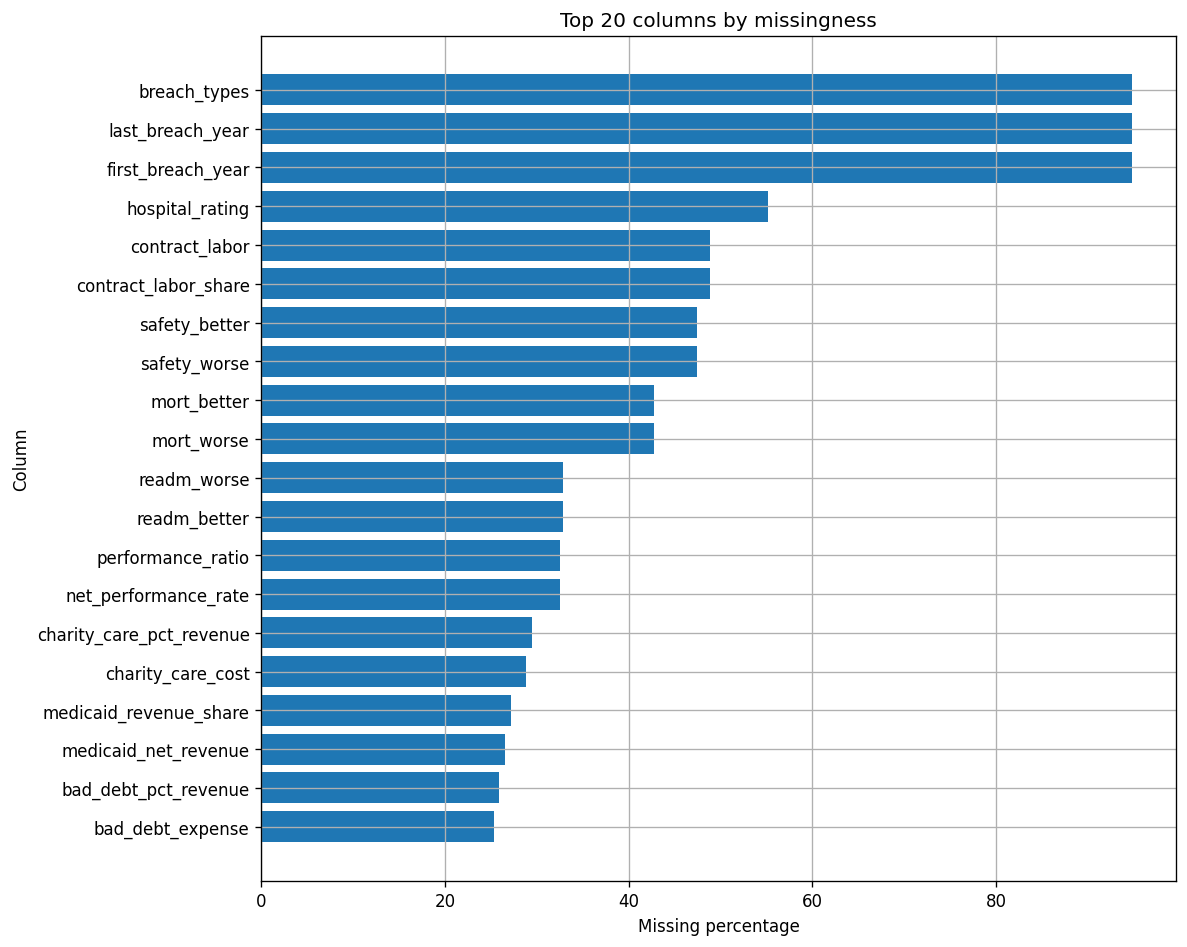

In [4]:
missing = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .rename("missing_pct")
      .reset_index()
      .rename(columns={"index": "column"})
)

display(missing.head(20))

top_missing = missing.head(20).sort_values("missing_pct")
plt.figure(figsize=(10, 8))
plt.barh(top_missing["column"], top_missing["missing_pct"])
plt.xlabel("Missing percentage")
plt.ylabel("Column")
plt.title("Top 20 columns by missingness")
plt.tight_layout()
plt.show()


In [5]:
missing_bands = pd.cut(
    missing["missing_pct"],
    bins=[-0.1, 0, 5, 20, 50, 100],
    labels=["0%", ">0% to 5%", ">5% to 20%", ">20% to 50%", ">50%"]
)
display(missing_bands.value_counts().sort_index().rename("column_count").to_frame())


,column_count
missing_pct,
0%,12
>0% to 5%,48
>5% to 20%,34
>20% to 50%,19
>50%,4


## 3. Duplicate and key-integrity checks

In [6]:
exact_duplicates = int(df.duplicated().sum())
ccn_year_duplicates = int(df.duplicated(subset=["ccn", "report_year"]).sum()) if {"ccn", "report_year"}.issubset(df.columns) else np.nan

integrity = pd.DataFrame({
    "check": ["exact duplicate rows", "duplicate (ccn, report_year) pairs"],
    "count": [exact_duplicates, ccn_year_duplicates]
})
display(integrity)

if {"ccn", "report_year"}.issubset(df.columns):
    dup_examples = (
        df[df.duplicated(subset=["ccn", "report_year"], keep=False)]
        .sort_values(["ccn", "report_year"])
        .head(10)
    )
    display(dup_examples[["ccn", "report_year"] + [c for c in ["hospital_type", "hospital_ownership", "had_ransomware", "had_breach"] if c in df.columns]])


,check,count
0,exact duplicate rows,15
1,"duplicate (ccn, report_year) pairs",953


,ccn,report_year,hospital_type,hospital_ownership,had_ransomware,had_breach
46,10008,2020,Acute Care,For-Profit,0,0
47,10008,2020,Acute Care,For-Profit,0,0
73,10016,2016,Acute Care,Non-Profit,0,0
74,10016,2016,Acute Care,Non-Profit,0,0
93,10019,2015,Acute Care,Government,0,0
94,10019,2015,Acute Care,Government,0,0
117,10022,2018,Acute Care,For-Profit,0,0
118,10022,2018,Acute Care,For-Profit,0,0
158,10032,2018,NaN,NaN,0,0
159,10032,2018,NaN,NaN,0,0


## 4. Target-variable exploration

,column,mean,sum,non_null
0,had_ransomware,0.029555,1816,61444
1,had_breach,0.051673,3175,61444
2,is_profitable,0.649453,39905,61444
3,high_charity,0.103899,6384,61444


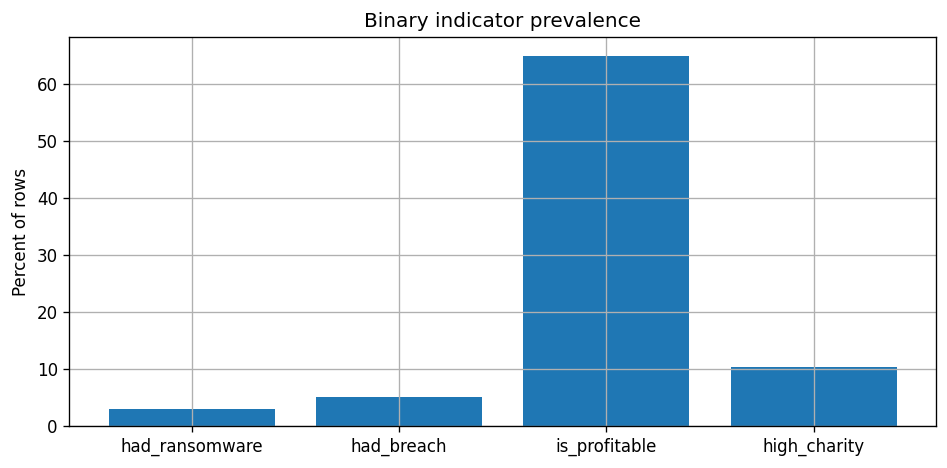

In [7]:
target_cols = [c for c in ["had_ransomware", "had_breach", "is_profitable", "high_charity"] if c in df.columns]

target_summary = pd.DataFrame({
    "column": target_cols,
    "mean": [df[c].mean() for c in target_cols],
    "sum": [df[c].sum() for c in target_cols],
    "non_null": [df[c].notna().sum() for c in target_cols]
})
display(target_summary)

if target_cols:
    plot_data = target_summary.copy()
    plot_data["mean_pct"] = plot_data["mean"] * 100
    plt.figure(figsize=(8, 4))
    plt.bar(plot_data["column"], plot_data["mean_pct"])
    plt.ylabel("Percent of rows")
    plt.title("Binary indicator prevalence")
    plt.tight_layout()
    plt.show()


,had_ransomware,had_breach
report_year,,
2014,2.86,5.04
2015,2.88,5.04
2016,2.88,5.09
2017,2.90,5.09
2018,2.94,5.18
2019,2.99,5.23
2020,3.00,5.25
2021,3.04,5.27
2022,3.02,5.24


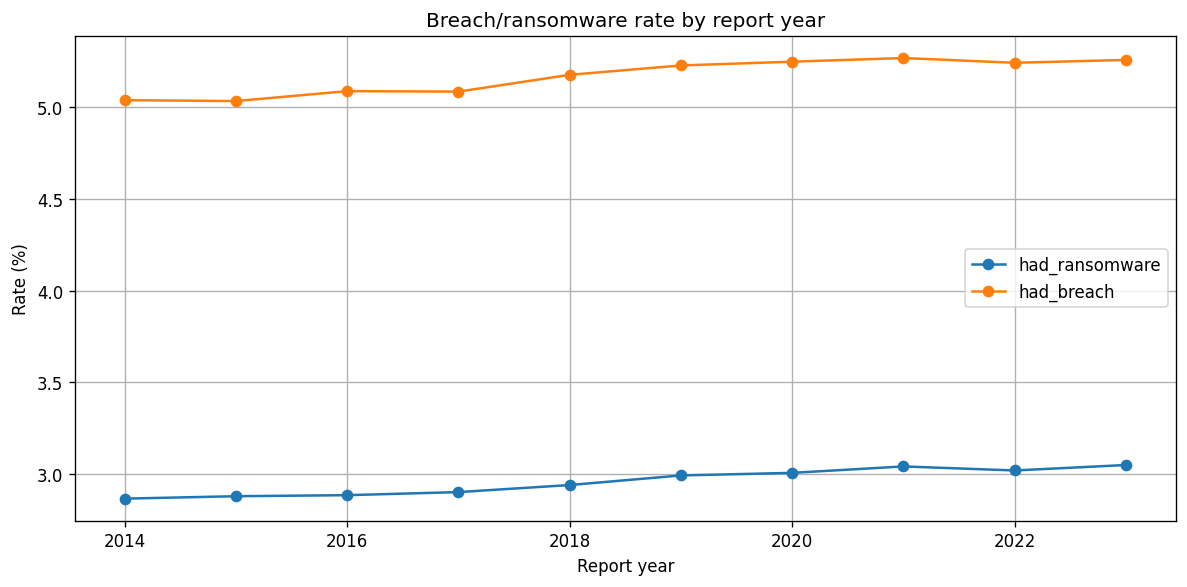

In [8]:
if "report_year" in df.columns and {"had_ransomware", "had_breach"}.issubset(df.columns):
    yearly_rates = df.groupby("report_year")[["had_ransomware", "had_breach"]].mean() * 100
    display(yearly_rates.round(2))

    plt.figure(figsize=(10, 5))
    plt.plot(yearly_rates.index, yearly_rates["had_ransomware"], marker="o", label="had_ransomware")
    plt.plot(yearly_rates.index, yearly_rates["had_breach"], marker="o", label="had_breach")
    plt.ylabel("Rate (%)")
    plt.xlabel("Report year")
    plt.title("Breach/ransomware rate by report year")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 5. Categorical-variable exploration

In [9]:
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()
categorical_cols


['bed_tier',
 'revenue_tier',
 'hospital_type',
 'hospital_ownership',
 'breach_types']

In [10]:
for col in categorical_cols:
    print(f"\n=== {col} ===")
    vc = df[col].value_counts(dropna=False).head(15)
    display(vc.to_frame("count"))



=== bed_tier ===


,count
bed_tier,
Micro,17580
Medium,12133
Major,12068
Large,12054
Small,6748
NaN,861



=== revenue_tier ===


,count
revenue_tier,
Q1_Low,14737
Q4_High,14736
Q3_Mid-High,14736
Q2_Mid-Low,14736
NaN,2499



=== hospital_type ===


,count
hospital_type,
Acute Care,30561
Rural/Access,13304
NaN,11227
Psychiatric,5433
Childrens,877
Long-term,42



=== hospital_ownership ===


,count
hospital_ownership,
Non-Profit,28527
Government,11366
NaN,11227
For-Profit,10324



=== breach_types ===


,count
breach_types,
NaN,58269
Hacking/IT Incident,1545
Unauthorized Access/Disclosure,688
Theft,302
Loss,150
Hacking/IT Incident|Unauthorized Access/Disclosure,131
Improper Disposal,80
Theft|Unauthorized Access/Disclosure,59
Other/Unknown,50


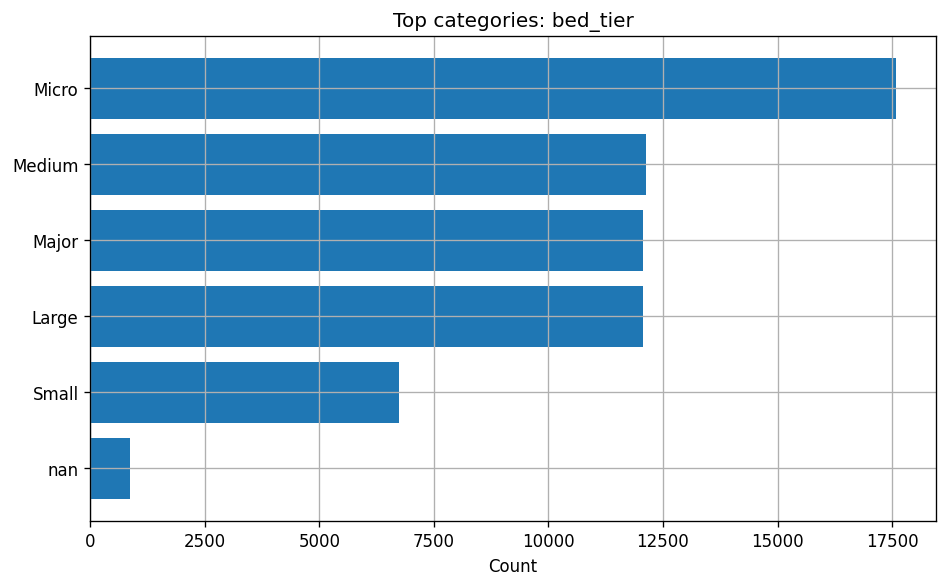

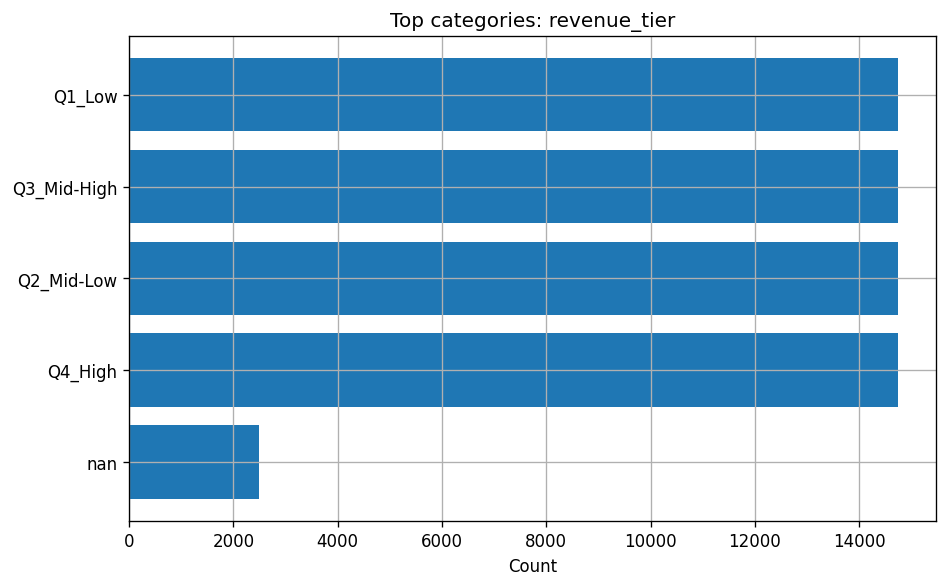

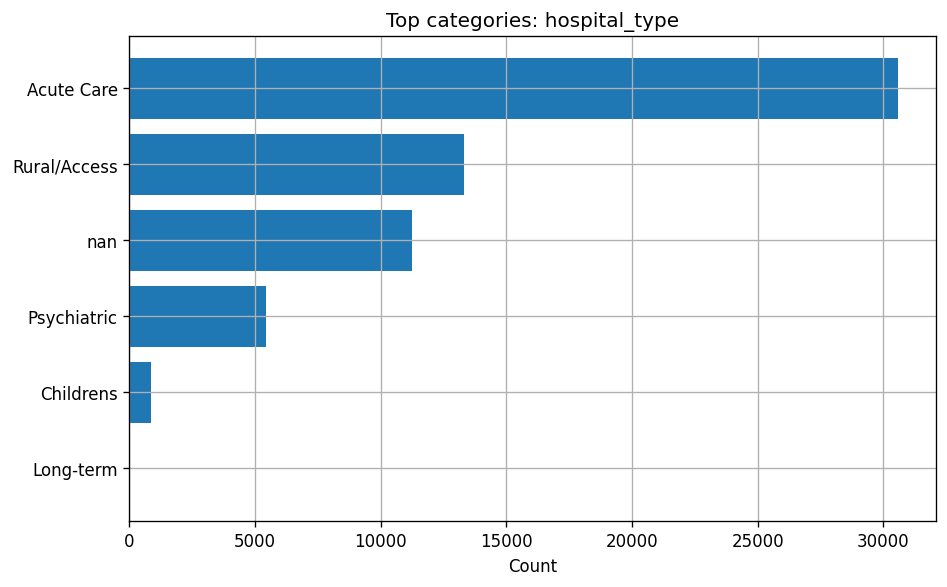

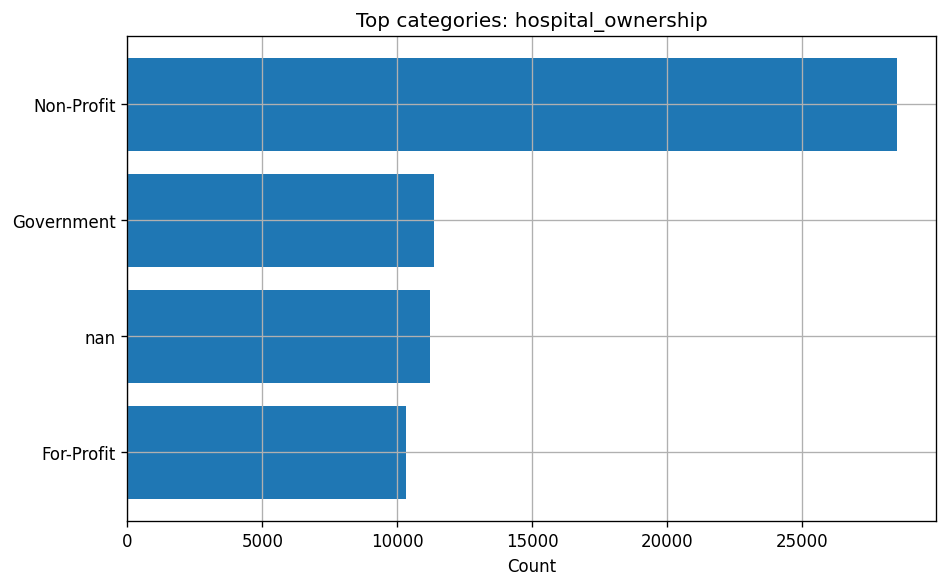

In [11]:
plot_candidates = [c for c in ["bed_tier", "revenue_tier", "hospital_type", "hospital_ownership"] if c in df.columns]

for col in plot_candidates:
    counts = df[col].value_counts(dropna=False).head(10).sort_values()
    plt.figure(figsize=(8, 5))
    plt.barh(counts.index.astype(str), counts.values)
    plt.title(f"Top categories: {col}")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()


## 6. Numeric summaries

In [12]:
numeric_df = df.select_dtypes(include=np.number)
summary_stats = numeric_df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
summary_stats["missing_pct"] = df[summary_stats.index].isna().mean() * 100
summary_stats["skew"] = numeric_df.skew(numeric_only=True)
display(summary_stats.sort_values("missing_pct", ascending=False).head(20))
display(summary_stats.loc[[c for c in ["net_patient_revenue", "total_costs", "net_income", "beds", "fte_employees", "occupancy_rate", "current_ratio", "debt_to_equity"] if c in summary_stats.index]])


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_pct,skew
last_breach_year,3175.0,2.019265e+03,4.011945e+00,2.010000e+03,2010.000000,2011.000000,2.017000e+03,2.020000e+03,2.022000e+03,2.024000e+03,2.025000e+03,2.025000e+03,94.832693,-0.806500
first_breach_year,3175.0,2.018409e+03,4.255680e+00,2.009000e+03,2010.000000,2010.000000,2.015000e+03,2.020000e+03,2.022000e+03,2.024000e+03,2.025000e+03,2.025000e+03,94.832693,-0.552024
hospital_rating,27563.0,3.027972e+00,1.080489e+00,1.000000e+00,1.000000,1.000000,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,55.141267,-0.056547
contract_labor,31401.0,6.053861e+06,1.521579e+07,-4.805000e+03,4966.000000,49661.000000,4.818440e+05,1.621006e+06,5.013535e+06,2.543624e+07,7.392141e+07,4.981880e+08,48.894929,7.552832
contract_labor_share,31401.0,2.835967e+03,2.438052e+05,-3.725393e-04,0.000257,0.002034,1.281076e-02,3.332121e-02,7.605441e-02,2.198559e-01,4.575949e-01,2.474981e+07,48.894929,91.006637
safety_better,32331.0,1.494899e-01,1.698575e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,1.428571e-01,2.500000e-01,5.000000e-01,6.250000e-01,1.000000e+00,47.381355,1.153994
safety_worse,32331.0,2.449400e-02,8.196252e-02,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.666667e-01,3.333333e-01,1.000000e+00,47.381355,6.178913
mort_worse,35164.0,2.645895e-02,9.209191e-02,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e-01,4.285714e-01,1.000000e+00,42.770653,5.294148
mort_better,35164.0,3.194873e-02,1.013934e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,2.500000e-01,5.000000e-01,1.000000e+00,42.770653,4.131984
readm_worse,41241.0,5.769416e-02,1.051783e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000e-01,2.727273e-01,4.285714e-01,1.000000e+00,32.880346,2.271537


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_pct,skew
net_patient_revenue,58945.0,1.836852e+08,3.775293e+08,-3.147621e+09,2.150425e+06,6.283934e+06,1.945374e+07,5.284673e+07,1.886960e+08,7.518806e+08,1.785518e+09,9.309984e+09,4.067118,6.376690
total_costs,60664.0,1.496808e+08,2.936903e+08,1.000000e+00,3.258975e+06,7.018377e+06,1.830391e+07,4.575263e+07,1.562211e+08,6.101657e+08,1.397461e+09,7.921780e+09,1.269449,6.145842
net_income,60555.0,1.001634e+07,8.774723e+07,-3.955820e+09,-1.296894e+08,-2.780792e+07,-1.002704e+06,1.734146e+06,1.060319e+07,7.858000e+07,2.299645e+08,7.919570e+09,1.446846,18.673349
beds,60583.0,1.325616e+02,1.746539e+02,1.000000e+00,8.000000e+00,1.500000e+01,2.500000e+01,6.500000e+01,1.700000e+02,4.590000e+02,8.041800e+02,4.106000e+03,1.401276,3.761532
fte_employees,60268.0,9.472065e+02,7.826073e+03,1.000000e-02,2.652670e+01,4.973350e+01,1.278575e+02,2.935100e+02,8.963725e+02,3.273706e+03,7.827365e+03,9.876470e+05,1.913938,101.243819
occupancy_rate,60499.0,5.041557e-01,2.692698e-01,1.095890e-05,3.508561e-02,1.058559e-01,3.008029e-01,5.133416e-01,6.977717e-01,8.859026e-01,9.753695e-01,1.967894e+01,1.537986,7.484645
current_ratio,58286.0,5.163209e+01,5.680442e+03,-5.119151e+05,-8.852652e+00,-2.303176e-01,9.493567e-01,1.852234e+00,3.242446e+00,9.134267e+00,2.932270e+01,9.185170e+05,5.139639,84.465244
debt_to_equity,58265.0,3.327057e+02,8.019728e+04,-4.147809e+04,-2.966757e+01,-5.175315e+00,4.024376e-02,4.188217e-01,1.157006e+00,6.245919e+00,3.323254e+01,1.935807e+07,5.173817,241.379114


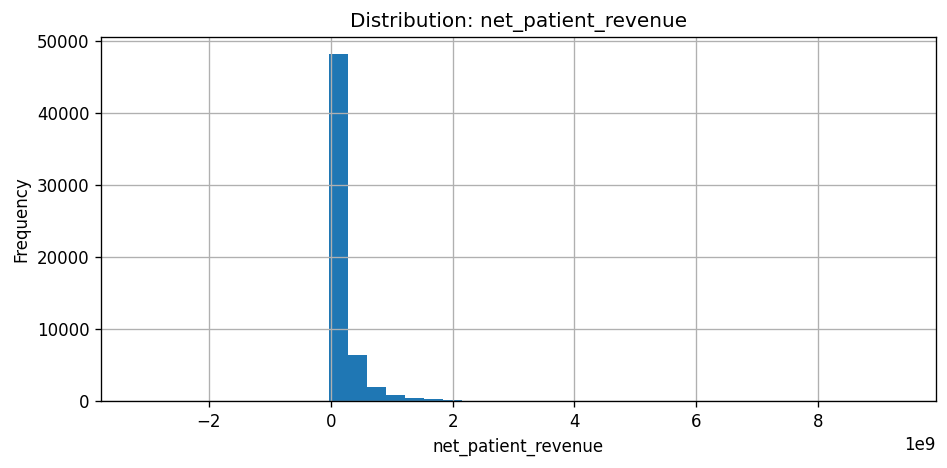

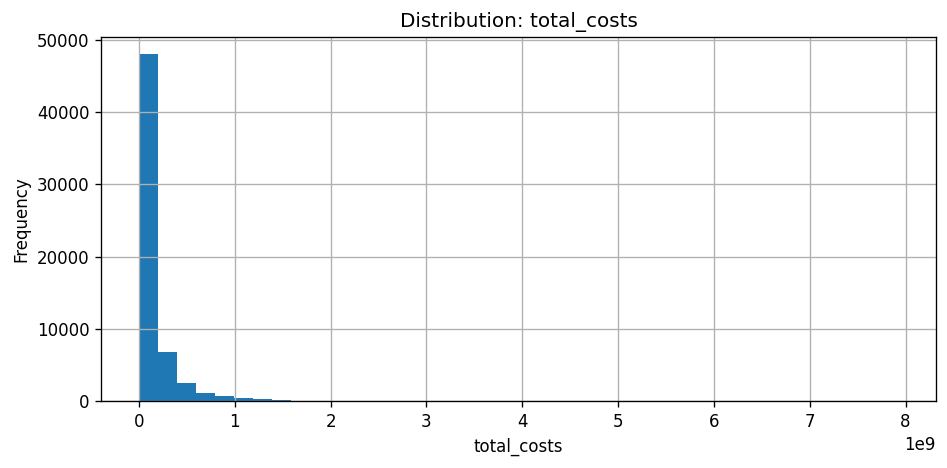

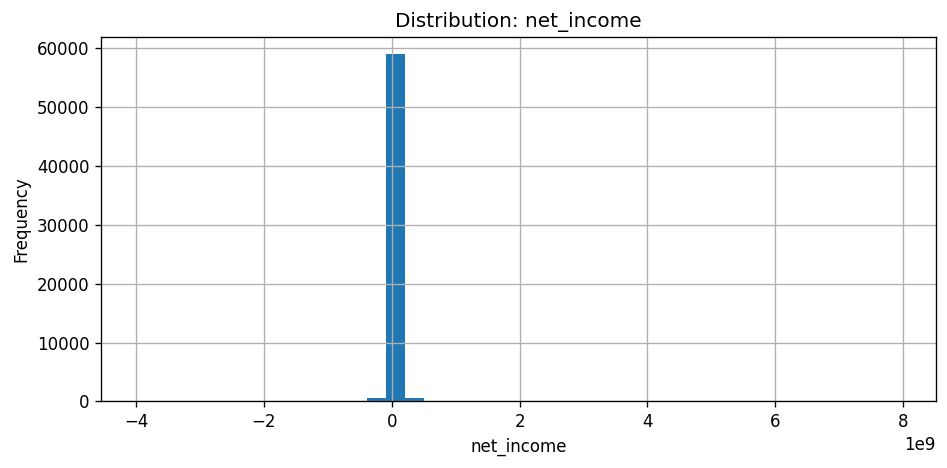

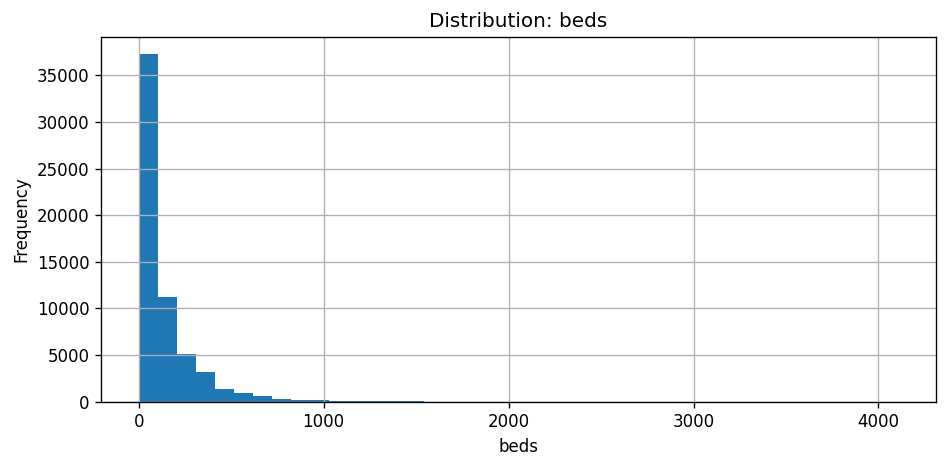

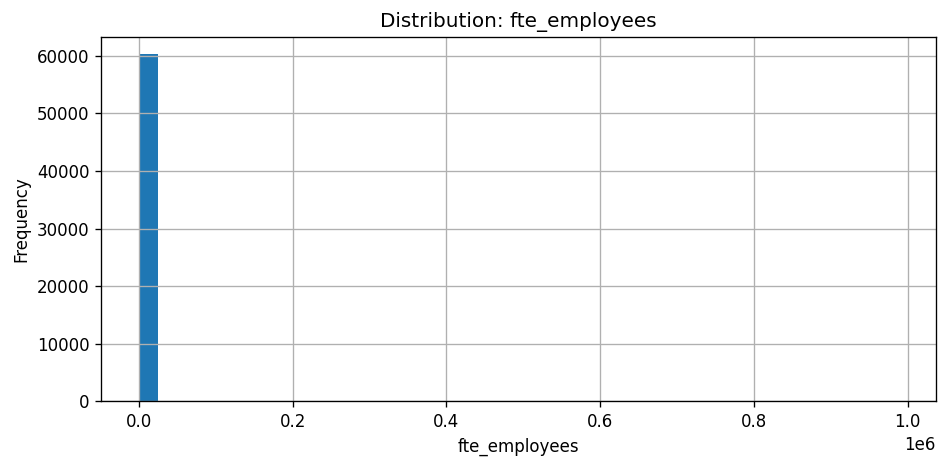

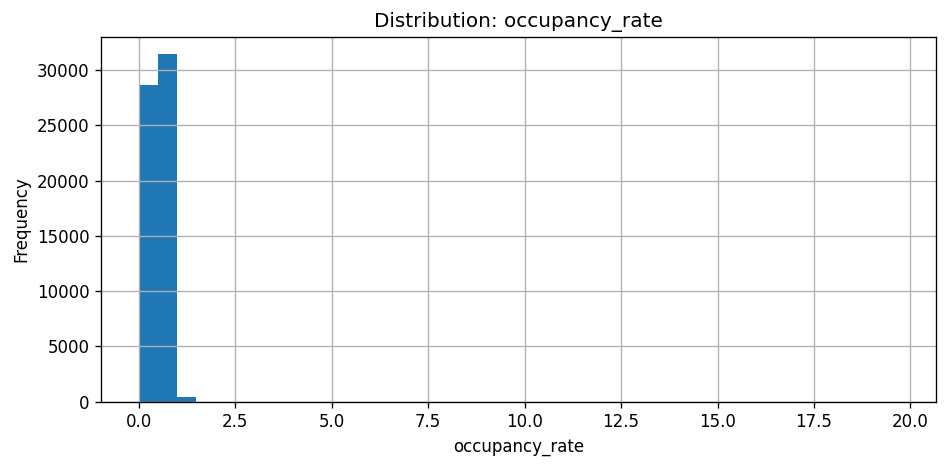

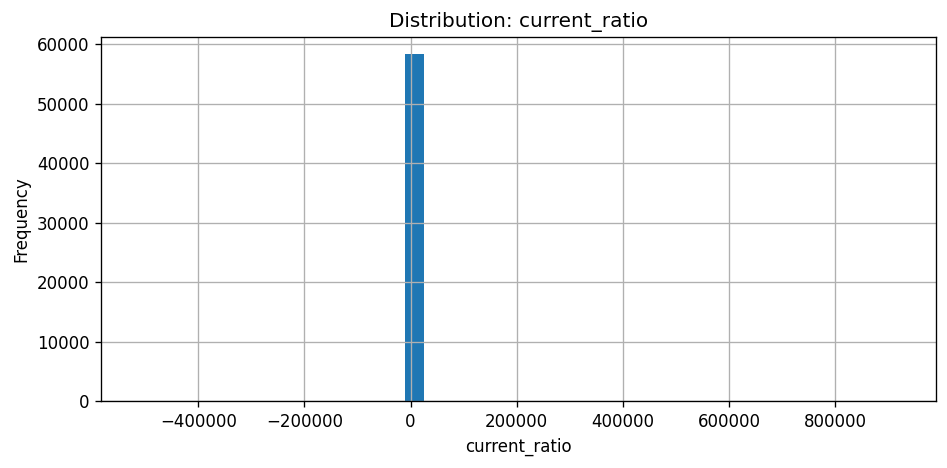

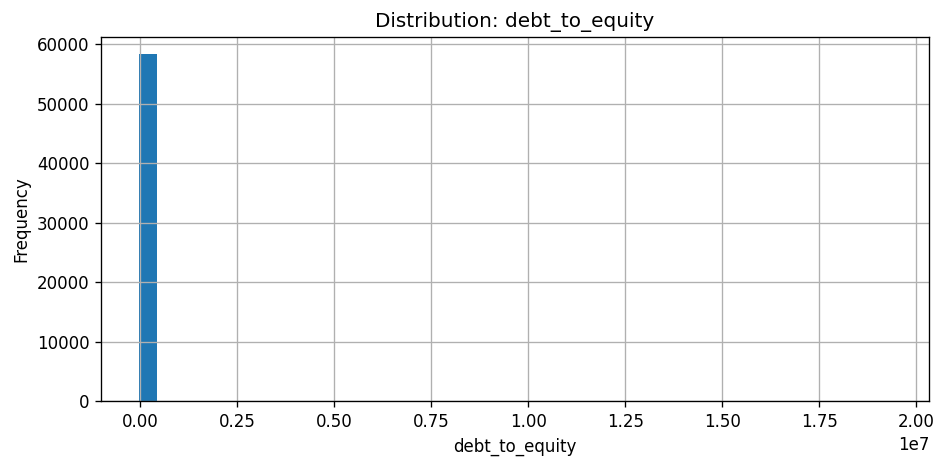

In [13]:
selected_numeric = [c for c in [
    "net_patient_revenue",
    "total_costs",
    "net_income",
    "beds",
    "fte_employees",
    "occupancy_rate",
    "current_ratio",
    "debt_to_equity"
] if c in df.columns]

for col in selected_numeric:
    series = df[col].dropna()
    if series.empty:
        continue
    plt.figure(figsize=(8, 4))
    plt.hist(series, bins=40)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


## 7. Time trends for selected measures

,net_patient_revenue,total_costs,net_income,beds,fte_employees
report_year,,,,,
2014,45740953.0,38353139.0,1560673.0,67.0,294.520
2015,46911186.0,39854831.0,1350827.5,65.0,292.370
2016,48530593.5,41893513.5,1259610.5,66.0,298.710
2017,50206529.5,43088271.5,1238204.5,66.0,302.205
2018,51490453.0,44615503.0,1203824.5,66.0,300.610
2019,51808884.5,45684880.0,1576250.0,66.0,293.620
2020,52028062.5,47320763.0,3700390.0,64.0,293.875
2021,58850731.0,52116149.0,3145640.0,65.0,291.370
2022,60709495.0,54352147.0,750973.0,64.0,288.250


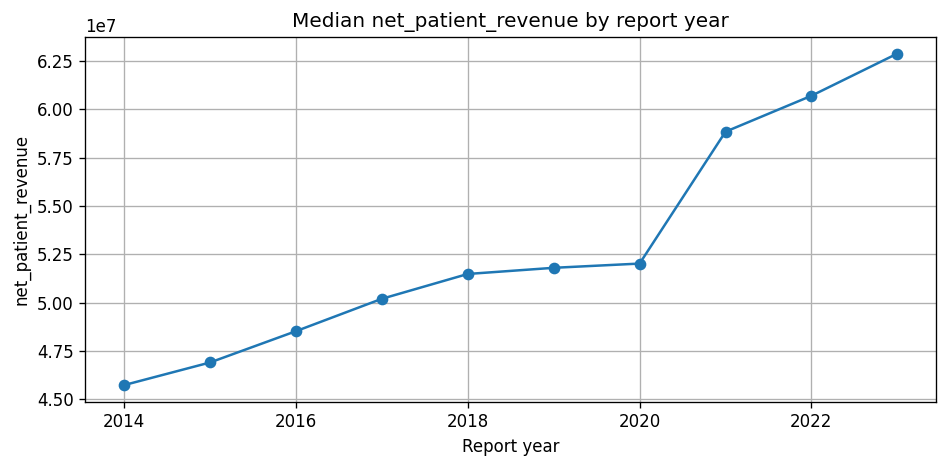

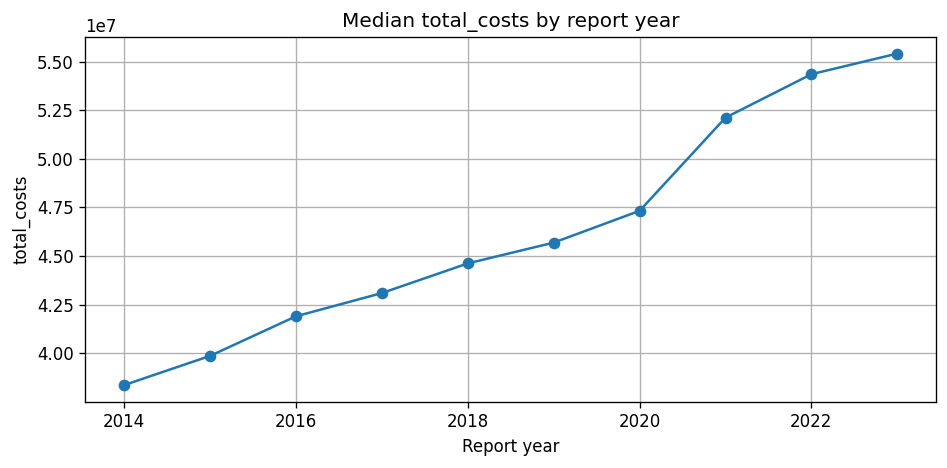

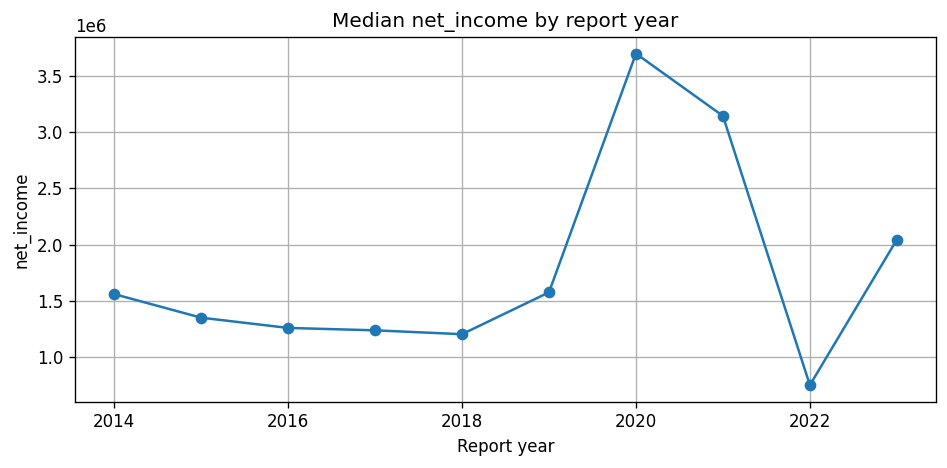

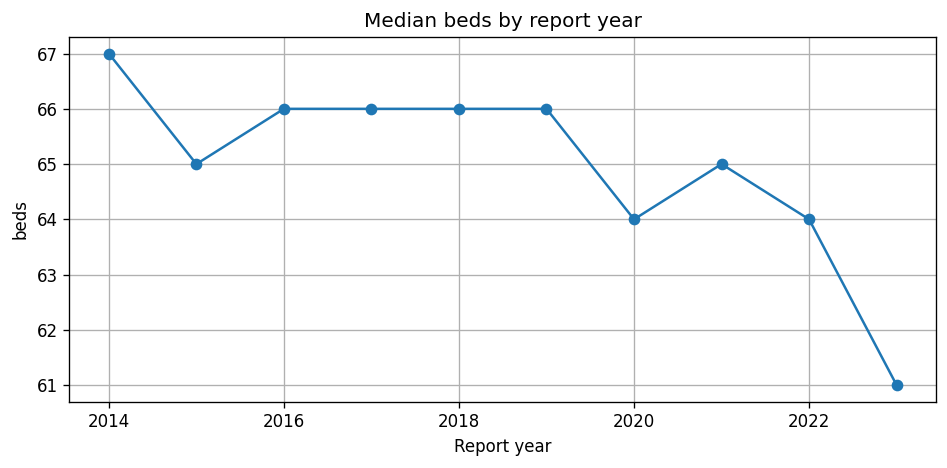

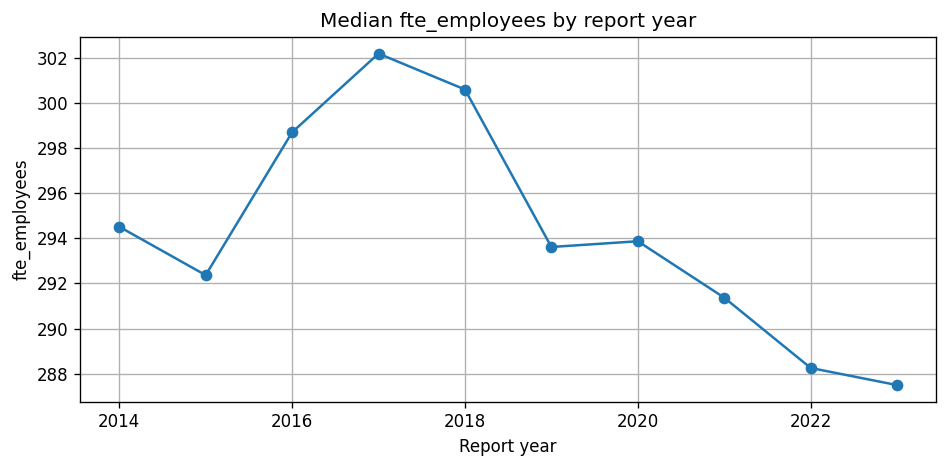

In [14]:
trend_cols = [c for c in ["net_patient_revenue", "total_costs", "net_income", "beds", "fte_employees"] if c in df.columns]
if "report_year" in df.columns and trend_cols:
    yearly_medians = df.groupby("report_year")[trend_cols].median()
    display(yearly_medians)

    for col in trend_cols:
        plt.figure(figsize=(8, 4))
        plt.plot(yearly_medians.index, yearly_medians[col], marker="o")
        plt.title(f"Median {col} by report year")
        plt.xlabel("Report year")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


## 8. Ransomware vs. non-ransomware comparison

In [15]:
compare_cols = [c for c in [
    "net_patient_revenue",
    "total_costs",
    "net_income",
    "beds",
    "fte_employees",
    "occupancy_rate",
    "current_ratio",
    "debt_to_equity",
    "net_profit_margin",
    "operating_margin"
] if c in df.columns]

if "had_ransomware" in df.columns:
    grp_median = df.groupby("had_ransomware")[compare_cols].median().T
    grp_mean = df.groupby("had_ransomware")[compare_cols].mean().T
    display(grp_median)
    display(grp_mean)


had_ransomware,0,1
net_patient_revenue,5.112523e+07,1.641234e+08
total_costs,4.458633e+07,1.273261e+08
net_income,1.702570e+06,4.535218e+06
beds,6.400000e+01,1.280000e+02
fte_employees,2.860000e+02,9.060700e+02
occupancy_rate,5.130691e-01,5.263848e-01
current_ratio,1.839528e+00,2.118757e+00
debt_to_equity,4.071871e-01,6.775271e-01
net_profit_margin,4.795189e-02,4.252756e-02
operating_margin,4.234985e-02,3.810057e-02


had_ransomware,0,1
net_patient_revenue,1.739675e+08,4.952290e+08
total_costs,1.421850e+08,3.942482e+08
net_income,9.279850e+06,3.400178e+07
beds,1.290222e+02,2.478864e+02
fte_employees,9.038474e+02,2.361273e+03
occupancy_rate,5.037546e-01,5.172127e-01
current_ratio,5.317262e+01,2.699744e+00
debt_to_equity,3.430253e+02,5.232549e+00
net_profit_margin,-9.787948e+02,4.345317e-02
operating_margin,3.222098e-02,3.542355e-02


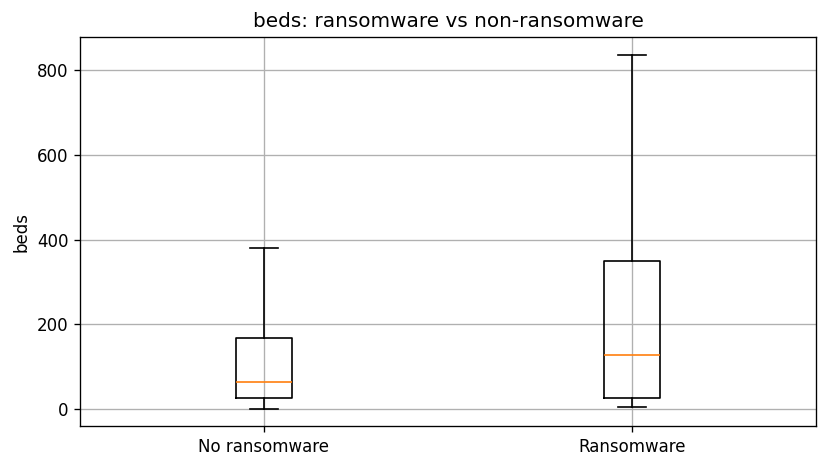

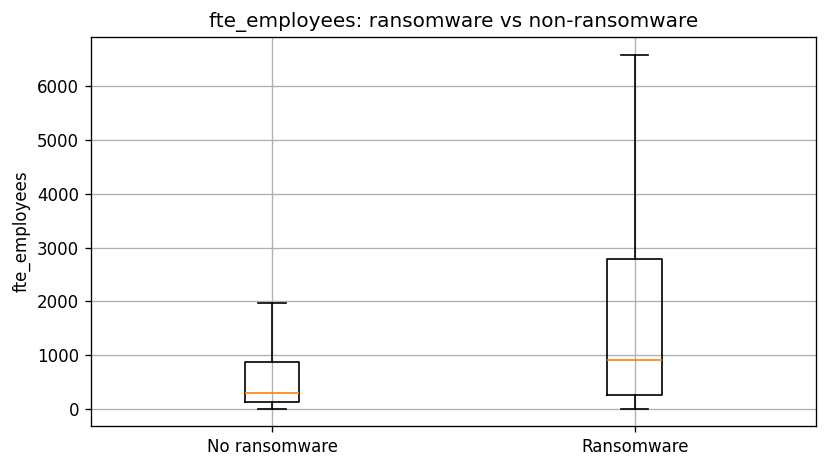

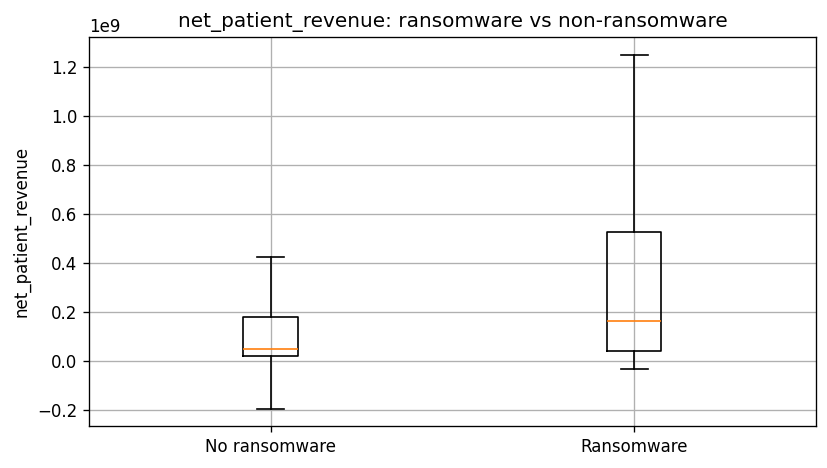

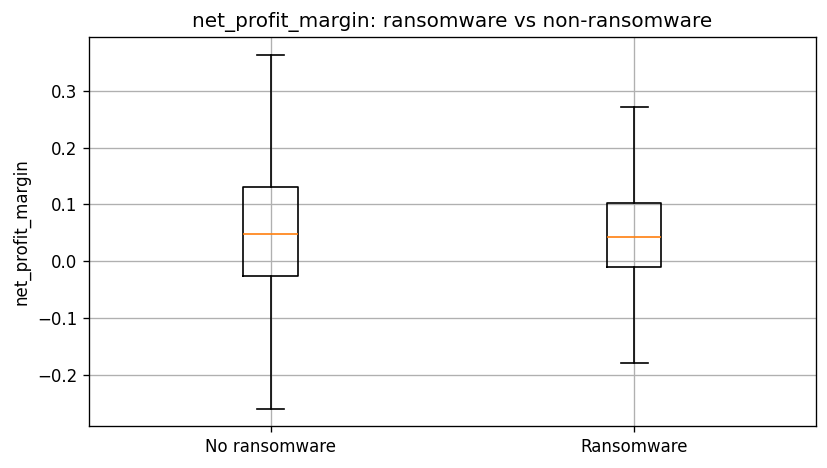

In [16]:
if "had_ransomware" in df.columns:
    for col in [c for c in ["beds", "fte_employees", "net_patient_revenue", "net_profit_margin"] if c in df.columns]:
        grouped = [
            df.loc[df["had_ransomware"] == 0, col].dropna(),
            df.loc[df["had_ransomware"] == 1, col].dropna()
        ]
        plt.figure(figsize=(7, 4))
        plt.boxplot(grouped, tick_labels=["No ransomware", "Ransomware"], showfliers=False)
        plt.title(f"{col}: ransomware vs non-ransomware")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


## 9. Correlation review

,net_patient_revenue,total_costs,net_income,beds,fte_employees,occupancy_rate,current_ratio,debt_to_equity,asset_turnover,equity_ratio,liability_ratio,net_profit_margin,operating_margin,had_ransomware,had_breach
net_patient_revenue,1.000,0.970,0.510,0.818,0.474,0.315,-0.002,-0.001,0.004,0.002,-0.004,0.000,0.091,0.146,0.190
total_costs,0.970,1.000,0.316,0.836,0.182,0.316,-0.002,-0.001,0.005,0.002,-0.003,0.002,0.035,0.146,0.193
net_income,0.510,0.316,1.000,0.274,0.056,0.104,0.000,-0.001,0.010,0.009,-0.002,-0.005,0.425,0.048,0.060
beds,0.818,0.836,0.274,1.000,0.163,0.346,-0.003,0.002,0.006,0.001,-0.004,0.006,0.020,0.116,0.173
fte_employees,0.474,0.182,0.056,0.163,1.000,0.078,-0.001,-0.001,0.001,0.000,-0.002,0.001,-0.031,0.032,0.041
occupancy_rate,0.315,0.316,0.104,0.346,0.078,1.000,0.002,-0.004,0.009,-0.002,-0.011,-0.002,0.040,0.008,0.038
current_ratio,-0.002,-0.002,0.000,-0.003,-0.001,0.002,1.000,-0.000,-0.000,0.000,-0.000,-0.000,0.004,-0.002,-0.002
debt_to_equity,-0.001,-0.001,-0.001,0.002,-0.001,-0.004,-0.000,1.000,-0.000,0.000,-0.000,-0.000,-0.002,-0.001,-0.001
asset_turnover,0.004,0.005,0.010,0.006,0.001,0.009,-0.000,-0.000,1.000,-0.003,0.035,-0.000,0.006,-0.002,-0.003
equity_ratio,0.002,0.002,0.009,0.001,0.000,-0.002,0.000,0.000,-0.003,1.000,-1.000,0.472,0.014,0.001,0.001


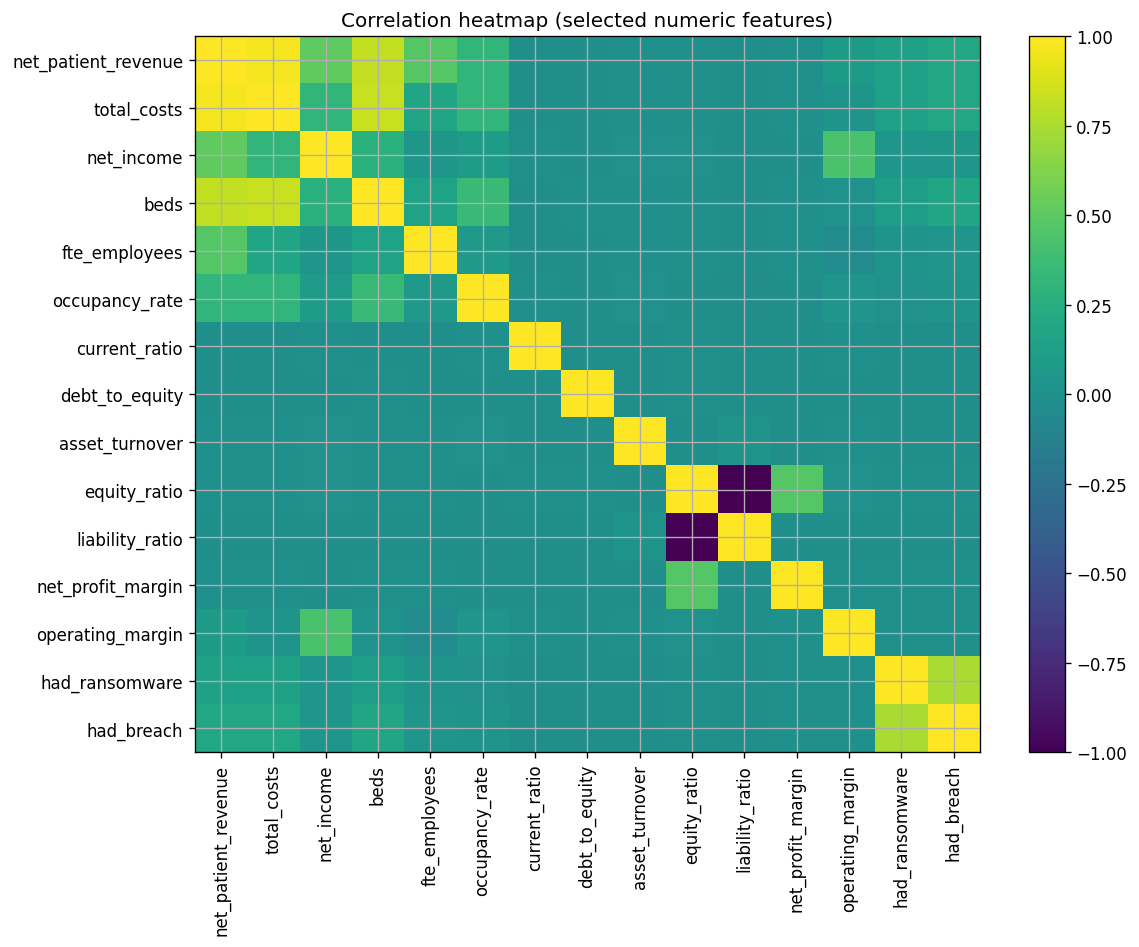

,corr_with_had_ransomware
had_ransomware,1.000000
had_breach,0.747618
total_costs,0.145788
net_patient_revenue,0.145745
beds,0.115679
net_income,0.047899
fte_employees,0.031640
occupancy_rate,0.008499
asset_turnover,-0.002345
current_ratio,-0.001528


In [17]:
corr_cols = [c for c in [
    "net_patient_revenue",
    "total_costs",
    "net_income",
    "beds",
    "fte_employees",
    "occupancy_rate",
    "current_ratio",
    "debt_to_equity",
    "asset_turnover",
    "equity_ratio",
    "liability_ratio",
    "net_profit_margin",
    "operating_margin",
    "had_ransomware",
    "had_breach"
] if c in df.columns]

corr = df[corr_cols].corr(numeric_only=True)
display(corr.round(3))

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation heatmap (selected numeric features)")
plt.tight_layout()
plt.show()

if "had_ransomware" in corr.columns:
    ransomware_corr = corr["had_ransomware"].sort_values(key=lambda s: s.abs(), ascending=False)
    display(ransomware_corr.to_frame("corr_with_had_ransomware"))


## 10. Modeling-readiness checks

In [18]:
constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
high_missing_cols = missing.loc[missing["missing_pct"] > 50, "column"].tolist()

readiness = {
    "constant_or_single_value_columns": constant_cols,
    "columns_above_50pct_missing": high_missing_cols[:50],
    "count_columns_above_50pct_missing": len(high_missing_cols)
}
readiness


{'constant_or_single_value_columns': [],
 'columns_above_50pct_missing': ['first_breach_year',
  'last_breach_year',
  'breach_types',
  'hospital_rating'],
 'count_columns_above_50pct_missing': 4}

In [19]:
candidate_ids = [c for c in ["ccn", "cbsa", "report_year", "first_breach_year", "last_breach_year"] if c in df.columns]
cardinality = pd.DataFrame({
    "column": candidate_ids,
    "nunique": [df[c].nunique(dropna=True) for c in candidate_ids],
    "missing_pct": [df[c].isna().mean() * 100 for c in candidate_ids]
})
display(cardinality)


,column,nunique,missing_pct
0,ccn,6804,0.000000
1,cbsa,597,1.267821
2,report_year,10,0.000000
3,first_breach_year,17,94.832693
4,last_breach_year,16,94.832693


## 11. Auto-generated key findings

In [20]:
findings = []

findings.append(f"The dataset contains {len(df):,} rows, {df.shape[1]:,} columns, and {df['ccn'].nunique():,} unique hospitals across report years {int(df['report_year'].min())}-{int(df['report_year'].max())}.")
findings.append(f"There are {int(df.duplicated().sum()):,} exact duplicate rows and {int(df.duplicated(subset=['ccn', 'report_year']).sum()):,} duplicate (ccn, report_year) pairs, so the hospital-year key is not unique.")
findings.append(f"Roughly {df['had_ransomware'].mean()*100:.2f}% of rows are flagged for ransomware and {df['had_breach'].mean()*100:.2f}% are flagged for any breach.")
findings.append(f"The most incomplete variables are first_breach_year, last_breach_year, and breach_types (each about {df[['first_breach_year','last_breach_year','breach_types']].isna().mean().mean()*100:.1f}% missing).")
findings.append(f"Hospital_rating is also sparse at {df['hospital_rating'].isna().mean()*100:.1f}% missing, while contract_labor and contract_labor_share are each about {df['contract_labor'].isna().mean()*100:.1f}% missing.")
findings.append(f"Median ransomware-flagged hospitals appear larger than non-ransomware hospitals by beds ({df.groupby('had_ransomware')['beds'].median().to_dict()}) and FTEs ({df.groupby('had_ransomware')['fte_employees'].median().round(2).to_dict()}).")
findings.append(f"Yearly ransomware rates are fairly stable in this panel, ranging from {df.groupby('report_year')['had_ransomware'].mean().min()*100:.2f}% to {df.groupby('report_year')['had_ransomware'].mean().max()*100:.2f}% across years.")
findings.append("Several financial variables are highly right-skewed, especially revenue, costs, and assets, so robust statistics, log transforms, or winsorization may help in downstream modeling.")

for i, item in enumerate(findings, start=1):
    print(f"{i}. {item}")


1. The dataset contains 61,444 rows, 117 columns, and 6,804 unique hospitals across report years 2014-2023.
2. There are 15 exact duplicate rows and 953 duplicate (ccn, report_year) pairs, so the hospital-year key is not unique.
3. Roughly 2.96% of rows are flagged for ransomware and 5.17% are flagged for any breach.
4. The most incomplete variables are first_breach_year, last_breach_year, and breach_types (each about 94.8% missing).
5. Hospital_rating is also sparse at 55.1% missing, while contract_labor and contract_labor_share are each about 48.9% missing.
6. Median ransomware-flagged hospitals appear larger than non-ransomware hospitals by beds ({0: 64.0, 1: 128.0}) and FTEs ({0: 286.0, 1: 906.07}).
7. Yearly ransomware rates are fairly stable in this panel, ranging from 2.86% to 3.05% across years.
8. Several financial variables are highly right-skewed, especially revenue, costs, and assets, so robust statistics, log transforms, or winsorization may help in downstream modeling.
